# Cardiac Strain Analysis — GRS & GCS

Computes **Global Radial Strain (GRS)** and **Global Circumferential Strain (GCS)**
from cardiac segmentation masks exported from VisHeart.

## Two modes

### Mode A — 4D file (full cardiac cycle)
- Upload ONE 4D NIfTI file with all frames (H × W × Slices × Frames)
- ED and ES frames are auto-detected from LV volume
- Output: strain curve across all frames + peak strain bullseye

### Mode B — Two 3D files (ED + ES only)
- Upload TWO 3D NIfTI files exported from VisHeart
- File 1 = ED frame (heart relaxed — largest LV, run segmentation on this frame)
- File 2 = ES frame (heart contracted — smallest LV, run segmentation on this frame)
- Output: single GRS and GCS value per segment + bullseye comparison

## How to get the files from VisHeart (Mode B)
1. Open your project in VisHeart
2. Scrub through frames — find the frame where LV looks BIGGEST → that is ED
3. Run segmentation on that frame → click Export Masks → save as `ed_mask.nii`
4. Find the frame where LV looks SMALLEST → that is ES
5. Run segmentation on that frame → click Export Masks → save as `es_mask.nii`
6. Run this notebook in Mode B

## Strain definitions
- **GRS** = (WT_ES − WT_ED) / WT_ED × 100%  — wall thickening  [normal > +40%]
- **GCS** = (Circ_ES − Circ_ED) / Circ_ED × 100%  — circumferential shortening  [normal −15% to −25%]

## Mask class convention
| Class | Structure |
|-------|-----------|
| 0 | Background |
| 1 | RV |
| 2 | Myocardium |
| 3 | LV cavity |

## How to run
1. Run **Install** cell once
2. Run **Configuration** cell — choose MODE and pick file(s)
3. Run all remaining cells

## 1. Install Dependencies

In [1]:
import subprocess, sys
result = subprocess.run(
    [sys.executable, "-m", "pip", "install",
     "nibabel", "numpy", "matplotlib", "scipy", "-q"],
    capture_output=True, text=True
)
print("Dependencies ready." if result.returncode == 0 else result.stderr)

Dependencies ready.


## 2. Imports

In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Wedge
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from scipy import ndimage
import nibabel as nib
import os

print("Imports OK.")

Imports OK.


## 3. Configuration

Choose **Mode A** (one 4D file) or **Mode B** (two 3D files: ED + ES).  
Run this cell to open the file browser(s) and set all path variables.

In [5]:
import tkinter as tk
from tkinter import filedialog
import os

def pick_nifti_file(title='Select NIfTI file'):
    """Open a native file browser dialog."""
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    path = filedialog.askopenfilename(
        title=title,
        filetypes=[('NIfTI files', '*.nii *.nii.gz'), ('All files', '*.*')]
    )
    root.destroy()
    return path if path else None

# ─── CHOOSE YOUR MODE ───────────────────────────────────────────
# MODE = 'A'  →  ONE 4D NIfTI file (all frames, auto-detect ED/ES)
# MODE = 'B'  →  TWO 3D NIfTI files from VisHeart Export Masks (ED + ES separately)
MODE = 'B'   # ← change to 'A' if you have a 4D file
# ────────────────────────────────────────────────────────────

N_RAYS = 360  # ray-casting resolution

print(f'Mode: {MODE}')
print()

NIFTI_PATH    = None  # Mode A
NIFTI_ED_PATH = None  # Mode B
NIFTI_ES_PATH = None  # Mode B

if MODE == 'A':
    print('Opening file browser — select your 4D segmentation NIfTI file...')
    NIFTI_PATH = pick_nifti_file('Select 4D segmentation NIfTI (all frames)')
    if NIFTI_PATH:
        print(f'Selected: {NIFTI_PATH}')
    else:
        print('No file selected. Re-run this cell.')

elif MODE == 'B':
    print('Step 1 of 2 — Select ED frame segmentation mask')
    print('  (ED = heart RELAXED = largest LV = exported from VisHeart at ED frame)')
    NIFTI_ED_PATH = pick_nifti_file('Select ED segmentation mask (heart relaxed — largest LV)')
    if NIFTI_ED_PATH:
        print(f'  ED selected: {NIFTI_ED_PATH}')
    else:
        print('  No ED file selected.')

    print()
    print('Step 2 of 2 — Select ES frame segmentation mask')
    print('  (ES = heart CONTRACTED = smallest LV = exported from VisHeart at ES frame)')
    NIFTI_ES_PATH = pick_nifti_file('Select ES segmentation mask (heart contracted — smallest LV)')
    if NIFTI_ES_PATH:
        print(f'  ES selected: {NIFTI_ES_PATH}')
    else:
        print('  No ES file selected.')

else:
    raise ValueError(f"Unknown MODE '{MODE}'. Set MODE = 'A' or MODE = 'B'.")

print()
print('Configuration complete. Run the next cell to load data.')


Mode: B

Step 1 of 2 — Select ED frame segmentation mask
  (ED = heart RELAXED = largest LV = exported from VisHeart at ED frame)
  ED selected: C:/Users/hp193/Downloads/patient005_frame01_segmentation.nii/patient005_frame01_segmentation.nii

Step 2 of 2 — Select ES frame segmentation mask
  (ES = heart CONTRACTED = smallest LV = exported from VisHeart at ES frame)
  ES selected: C:/Users/hp193/Downloads/patient005_frame13_segmentation.nii/patient005_frame13_segmentation.nii

Configuration complete. Run the next cell to load data.


## 4. Load Segmentation Mask(s)

**Mode A**: loads one 4D file, normalises to (H × W × Slices × Frames), auto-detects ED/ES.  
**Mode B**: loads two 3D files (ED + ES) and stacks them into a 2-frame array so all
downstream cells (ray-casting, strain, bullseye) work identically.

In [6]:
import os
import nibabel as nib
import numpy as np

def load_mask(path, label):
    """Load a NIfTI segmentation mask. Returns 3D uint8 array."""
    if path is None:
        raise ValueError(f'No {label} file selected. Re-run the Configuration cell.')
    if not os.path.exists(path):
        raise FileNotFoundError(f'File not found: {path}')
    nii   = nib.load(path)
    data  = nii.get_fdata().astype(np.uint8)
    zooms = nii.header.get_zooms()
    # Squeeze any trailing single-frame dimension
    while data.ndim > 3 and data.shape[-1] == 1:
        data = data[..., 0]
    if data.ndim == 4:
        # Multiple frames — pick the one with most myocardium
        myo_counts = [np.sum(data[:,:,:,f]==2) for f in range(data.shape[3])]
        best = int(np.argmax(myo_counts))
        print(f'  {label}: 4D file with {data.shape[3]} frames — using frame {best} (most myocardium)')
        data = data[:,:,:,best]
    assert data.ndim == 3, f'Expected 3D mask after loading, got {data.shape}'
    return data, zooms

if MODE == 'A':
    # ── Mode A: single 4D file ─────────────────────────────────────────────────────
    if not NIFTI_PATH or not os.path.exists(NIFTI_PATH):
        raise FileNotFoundError('No file selected. Re-run the Configuration cell.')

    nii   = nib.load(NIFTI_PATH)
    data  = nii.get_fdata().astype(np.uint8)
    zooms = nii.header.get_zooms()

    print(f'Raw shape  : {data.shape}')
    print(f'Voxel size : {zooms}')
    print(f'Classes    : {np.unique(data)}')

    if data.ndim == 3:
        data = data[:, :, :, np.newaxis]
        print('3D file — treated as 1 frame.')
    elif data.ndim == 4:
        print(f'4D file — {data.shape[3]} frames.')
    else:
        raise ValueError(f'Unexpected shape: {data.shape}')

    n_frames = data.shape[3]
    n_slices = data.shape[2]
    vox_xy   = float(zooms[0])

    if n_frames < 2:
        raise ValueError('Only 1 frame found. Mode A requires at least 2 frames.')

    lv_vols  = [np.sum(data[:, :, :, f] == 3) for f in range(n_frames)]
    ed_frame = int(np.argmax(lv_vols))
    es_frame = int(np.argmin(lv_vols))

    print(f'\nFrames : {n_frames}')
    print(f'Slices : {n_slices}')
    print(f'Voxel  : {vox_xy:.4f} mm/px')
    print(f'ED auto-detected: frame {ed_frame}  (LV={lv_vols[ed_frame]} px — largest)')
    print(f'ES auto-detected: frame {es_frame}  (LV={lv_vols[es_frame]} px — smallest)')
    print()
    for f in range(n_frames):
        lv  = np.sum(data[:, :, :, f] == 3)
        myo = np.sum(data[:, :, :, f] == 2)
        marker = ' <- ED' if f==ed_frame else (' <- ES' if f==es_frame else '')
        print(f'  Frame {f:2d}: LV={lv:5d} px, Myo={myo:5d} px{marker}')

elif MODE == 'B':
    # ── Mode B: two separate 3D files (ED + ES) ────────────────────────────────────
    print('Loading ED mask...')
    mask_ed, zooms = load_mask(NIFTI_ED_PATH, 'ED')
    print('Loading ES mask...')
    mask_es, _     = load_mask(NIFTI_ES_PATH, 'ES')

    assert mask_ed.shape == mask_es.shape, \
        f'ED and ES masks must have the same shape. Got {mask_ed.shape} vs {mask_es.shape}'

    vox_xy   = float(zooms[0])
    n_slices = mask_ed.shape[2]
    n_frames = 2  # ED=0, ES=1

    # Stack into (H, W, Slices, 2) so downstream code works identically
    data     = np.stack([mask_ed, mask_es], axis=3)
    ed_frame = 0
    es_frame = 1

    print(f'\nED mask shape : {mask_ed.shape}')
    print(f'ES mask shape : {mask_es.shape}')
    print(f'Voxel         : {vox_xy:.4f} mm/px')
    print(f'Slices        : {n_slices}')
    print()
    print('ED mask classes:', np.unique(mask_ed))
    print('ES mask classes:', np.unique(mask_es))
    print()
    for s in range(n_slices):
        lv_ed  = np.sum(mask_ed[:,:,s]==3)
        lv_es  = np.sum(mask_es[:,:,s]==3)
        myo_ed = np.sum(mask_ed[:,:,s]==2)
        myo_es = np.sum(mask_es[:,:,s]==2)
        print(f'  Slice {s:2d}: ED LV={lv_ed:4d} Myo={myo_ed:4d} | ES LV={lv_es:4d} Myo={myo_es:4d}')

print('\nData loaded. Run the next cell.')


Loading ED mask...
Loading ES mask...

ED mask shape : (256, 216, 10)
ES mask shape : (256, 216, 10)
Voxel         : 1.0000 mm/px
Slices        : 10

ED mask classes: [0 1 2 3]
ES mask classes: [0 1 2 3]

  Slice  0: ED LV=1745 Myo=1222 | ES LV=1133 Myo=1043
  Slice  1: ED LV=2141 Myo=1289 | ES LV=1467 Myo=1358
  Slice  2: ED LV=2074 Myo=1307 | ES LV=1496 Myo=1527
  Slice  3: ED LV=1949 Myo=1301 | ES LV=1554 Myo=1507
  Slice  4: ED LV=1771 Myo=1229 | ES LV=1466 Myo=1443
  Slice  5: ED LV=1657 Myo=1124 | ES LV=1399 Myo=1318
  Slice  6: ED LV=1439 Myo= 939 | ES LV=1298 Myo=1195
  Slice  7: ED LV=1082 Myo= 833 | ES LV=1002 Myo= 989
  Slice  8: ED LV= 697 Myo= 625 | ES LV= 614 Myo= 737
  Slice  9: ED LV= 228 Myo= 308 | ES LV= 206 Myo= 352

Data loaded. Run the next cell.


## 5. Wall Thickness Computation (All Frames)

For each frame and each valid slice:
1. Find LV centroid from class 3 pixels using `scipy.ndimage.center_of_mass`
2. Cast 360 rays radially outward from the centroid
3. Per ray: find **inner radius** (first non-LV pixel = LV→myocardium boundary) and **outer radius** (last myocardium pixel)
4. Wall thickness per ray = outer − inner radius
5. Average across valid rays → per-slice mean wall thickness
6. Rays are grouped into AHA sectors and mapped to 17 segments

Slices with < 10 LV pixels, < 10 myocardium pixels, or < 36 valid rays are skipped.

In [7]:
# Works for both Mode A (4D, n_frames=30) and Mode B (2 frames: ED=0, ES=1)

# ── Ray-casting helpers ───────────────────────────────────────────────────────

def compute_centroid(sl):
    """LV centroid from class 3 pixels. Returns (row, col) or None."""
    lv = (sl == 3).astype(float)
    if lv.sum() < 10:
        return None
    M = ndimage.center_of_mass(lv)
    return M[0], M[1]


def ray_cast(sl, cx, cy, angle_deg, max_r=300):
    """
    Cast one ray. Returns (inner_radius, outer_radius) in pixels or (None, None).
    inner = first pixel NOT LV cavity (LV->myo boundary)
    outer = last pixel that IS myocardium
    """
    H, W = sl.shape
    dx   = np.cos(np.deg2rad(angle_deg))
    dy   = np.sin(np.deg2rad(angle_deg))
    inner_r = outer_r = None
    for r in range(1, max_r):
        x, y   = cx + r * dx, cy + r * dy
        xi, yi = int(round(x)), int(round(y))
        if xi < 0 or xi >= W or yi < 0 or yi >= H:
            break
        pix = sl[yi, xi]
        if inner_r is None and pix != 3:
            inner_r = r
        if inner_r is not None and pix == 2:
            outer_r = r
        if inner_r is not None and outer_r is not None and pix not in [2, 3]:
            break
    return inner_r, outer_r


def compute_frame_metrics(frame_mask, n_rays=N_RAYS):
    """
    For one 3D frame mask, compute per-slice metrics.

    Returns
    -------
    slice_wt     : list of mean wall thickness (px) per valid slice
    slice_ir     : list of mean inner radius (px) per valid slice
    slice_rays   : list of per-ray thickness lists per valid slice
    valid_slices : list of valid slice indices
    """
    slice_wt, slice_ir, slice_rays, valid_slices = [], [], [], []
    for s in range(frame_mask.shape[2]):
        sl = frame_mask[:, :, s]
        if np.sum(sl == 3) < 10 or np.sum(sl == 2) < 10:
            continue
        c = compute_centroid(sl)
        if c is None:
            continue
        cy, cx = c
        rays, inners = [], []
        for a in range(n_rays):
            ir, or_ = ray_cast(sl, cx, cy, a)
            if ir and or_ and or_ > ir:
                rays.append(or_ - ir)
                inners.append(ir)
            else:
                rays.append(None)
                inners.append(None)
        valid_r = [t for t in rays   if t is not None]
        valid_i = [t for t in inners if t is not None]
        if len(valid_r) < 36:
            continue
        slice_wt.append(np.mean(valid_r))
        slice_ir.append(np.mean(valid_i))
        slice_rays.append(rays)
        valid_slices.append(s)
    return slice_wt, slice_ir, slice_rays, valid_slices


def classify_slices(n_valid):
    """Classify n_valid slices into basal/mid/apical/apex."""
    n_apex      = 1
    n_remaining = max(n_valid - n_apex, 3)
    n_basal     = max(1, round(n_remaining / 3))
    n_mid       = max(1, round(n_remaining / 3))
    n_apical    = max(1, n_remaining - n_basal - n_mid)
    while n_basal + n_mid + n_apical > n_remaining and n_basal > 1:
        n_basal -= 1
    labels = (['basal'] * n_basal + ['mid'] * n_mid +
               ['apical'] * n_apical + ['apex'] * n_apex)
    return labels[:n_valid]


def metrics_to_17_segments(slice_wt, slice_ir, slice_labels):
    """
    Map per-slice wall thickness and inner radius to 17 AHA segments.

    Returns (wt_17, circ_17) both in pixels.
    circ = 2*pi*mean_inner_radius per ring, spread across segments in that ring.
    """
    ring_defs = [('basal', 6), ('mid', 6), ('apical', 4), ('apex', 1)]
    wt_17   = []
    circ_17 = []
    for ring, n_sec in ring_defs:
        idxs = [i for i, l in enumerate(slice_labels) if l == ring]
        # Wall thickness: mean across all slices in ring, replicated per sector
        wt_vals = [slice_wt[i] for i in idxs]
        wt_mean = np.mean(wt_vals) if wt_vals else np.nan
        wt_17.extend([wt_mean] * n_sec)
        # Inner radius: mean per ring -> circumference
        ir_vals  = [slice_ir[i] for i in idxs]
        mean_ir  = np.mean(ir_vals) if ir_vals else np.nan
        circ_val = 2 * np.pi * mean_ir if not np.isnan(mean_ir) else np.nan
        circ_17.extend([circ_val] * n_sec)
    return wt_17, circ_17


# ── Compute for all frames ─────────────────────────────────────────────────────
print("Computing wall thickness and inner radius for all frames...\n")

all_frame_wt   = []
all_frame_circ = []

for f in range(n_frames):
    frame_mask = data[:, :, :, f]
    s_wt, s_ir, s_rays, v_slices = compute_frame_metrics(frame_mask)

    if len(v_slices) == 0:
        print(f"  Frame {f:2d}: no valid slices — NaN")
        all_frame_wt.append([np.nan] * 17)
        all_frame_circ.append([np.nan] * 17)
        continue

    labels = classify_slices(len(v_slices))
    wt_17, circ_17 = metrics_to_17_segments(s_wt, s_ir, labels)
    all_frame_wt.append(wt_17)
    all_frame_circ.append(circ_17)

    mean_wt_mm = np.nanmean([w for w in wt_17   if not np.isnan(w)]) * vox_xy
    mean_ir_mm = np.nanmean([c / (2 * np.pi) for c in circ_17 if not np.isnan(c)]) * vox_xy
    print(f"  Frame {f:2d}: {len(v_slices)} slices, "
          f"mean WT={mean_wt_mm:.2f} mm, mean inner_r={mean_ir_mm:.2f} mm")

all_frame_wt   = np.array(all_frame_wt,   dtype=float)   # (n_frames, 17)
all_frame_circ = np.array(all_frame_circ, dtype=float)   # (n_frames, 17)

# Auto-detect ED (largest LV) and ES (smallest LV)
lv_vols  = [np.sum(data[:, :, :, f] == 3) for f in range(n_frames)]
ed_frame = int(np.argmax(lv_vols))
es_frame = int(np.argmin(lv_vols))
print(f"\nED frame (largest LV) : {ed_frame}  (LV={lv_vols[ed_frame]} px)")
print(f"ES frame (smallest LV): {es_frame}  (LV={lv_vols[es_frame]} px)")
print(f"Shape: wt={all_frame_wt.shape}, circ={all_frame_circ.shape}")

Computing wall thickness and inner radius for all frames...

  Frame  0: 10 slices, mean WT=5.68 mm, mean inner_r=22.51 mm
  Frame  1: 10 slices, mean WT=7.06 mm, mean inner_r=20.01 mm

ED frame (largest LV) : 0  (LV=14783 px)
ES frame (smallest LV): 1  (LV=11635 px)
Shape: wt=(2, 17), circ=(2, 17)


## 6. Compute Frame-by-Frame Strain

For each consecutive frame pair (f → f+1) and each AHA segment:
- **GRS** = (WT[f+1] − WT[f]) / WT[f] × 100%
- **GCS** = (Circ[f+1] − Circ[f]) / Circ[f] × 100%

Global strain per transition = mean across all 17 segments.  
**Peak GRS** = transition with highest global GRS.  
**Peak GCS** = transition with most negative global GCS.

In [9]:
# Mode A: strain computed across all frames (n_frames=30)
# Mode B: strain computed for ED→ES only (n_frames=2, frame 0=ED, frame 1=ES)

AHA_NAMES = [
    'Basal Anterior',    'Basal Anterolateral', 'Basal Inferolateral',
    'Basal Inferior',    'Basal Inferoseptal',   'Basal Anteroseptal',
    'Mid Anterior',      'Mid Anterolateral',    'Mid Inferolateral',
    'Mid Inferior',      'Mid Inferoseptal',     'Mid Anteroseptal',
    'Apical Anterior',   'Apical Lateral',       'Apical Inferior',
    'Apical Septal',     'Apex'
]

# Reference = ED frame (largest LV volume = relaxed/diastolic state)
wt_ed   = all_frame_wt[ed_frame]    # (17,)
circ_ed = all_frame_circ[ed_frame]  # (17,)

# GRS[f, seg] = (WT[f,seg] - WT[ED,seg]) / WT[ED,seg] * 100
# GCS[f, seg] = (Circ[f,seg] - Circ[ED,seg]) / Circ[ED,seg] * 100
grs_all = np.full((n_frames, 17), np.nan)
gcs_all = np.full((n_frames, 17), np.nan)

for f in range(n_frames):
    for seg in range(17):
        if (not np.isnan(wt_ed[seg]) and not np.isnan(all_frame_wt[f, seg])
                and wt_ed[seg] > 0):
            grs_all[f, seg] = (all_frame_wt[f, seg] - wt_ed[seg]) / wt_ed[seg] * 100
        if (not np.isnan(circ_ed[seg]) and not np.isnan(all_frame_circ[f, seg])
                and circ_ed[seg] > 0):
            gcs_all[f, seg] = (all_frame_circ[f, seg] - circ_ed[seg]) / circ_ed[seg] * 100

# Global strain per frame = mean across all 17 segments
global_grs = np.nanmean(grs_all, axis=1)   # (n_frames,)
global_gcs = np.nanmean(gcs_all, axis=1)   # (n_frames,)

# Peak GRS = frame with highest wall thickening (most positive)
# Peak GCS = frame with most negative circumferential shortening
peak_grs_f = int(np.nanargmax(global_grs))
peak_gcs_f = int(np.nanargmin(global_gcs))

print(f"ED frame (reference, strain=0): {ed_frame}")
print(f"ES frame (expected peak strain): {es_frame}")
print()
print("Per-frame Global Strain (relative to ED):")
print(f"{'Frame':>6}  {'GRS (%)':>9}  {'GCS (%)':>9}")
print("-" * 32)
for f in range(n_frames):
    g  = f"{global_grs[f]:+.2f}" if not np.isnan(global_grs[f]) else "  N/A"
    c  = f"{global_gcs[f]:+.2f}" if not np.isnan(global_gcs[f]) else "  N/A"
    pk = ""
    if f == ed_frame:                    pk += " <- ED (ref)"
    if f == es_frame:                    pk += " <- ES"
    if f == peak_grs_f and f != ed_frame: pk += " <- peak GRS"
    if f == peak_gcs_f and f != ed_frame: pk += " <- peak GCS"
    print(f"  {f:3d}      {g:>9}  {c:>9}{pk}")

print(f"\nPeak GRS: frame {peak_grs_f} = {global_grs[peak_grs_f]:+.2f}%  (normal > +40%)")
print(f"Peak GCS: frame {peak_gcs_f} = {global_gcs[peak_gcs_f]:+.2f}%  (normal -15% to -25%)")

ED frame (reference, strain=0): 0
ES frame (expected peak strain): 1

Per-frame Global Strain (relative to ED):
 Frame    GRS (%)    GCS (%)
--------------------------------
    0          +0.00      +0.00 <- ED (ref)
    1         +24.11     -10.42 <- ES <- peak GRS <- peak GCS

Peak GRS: frame 1 = +24.11%  (normal > +40%)
Peak GCS: frame 1 = -10.42%  (normal -15% to -25%)


## 7. Strain Curves Across Cardiac Cycle

Shows how global GRS and GCS evolve across all frame transitions.  
The peak strain frame pair is highlighted with a red dot.

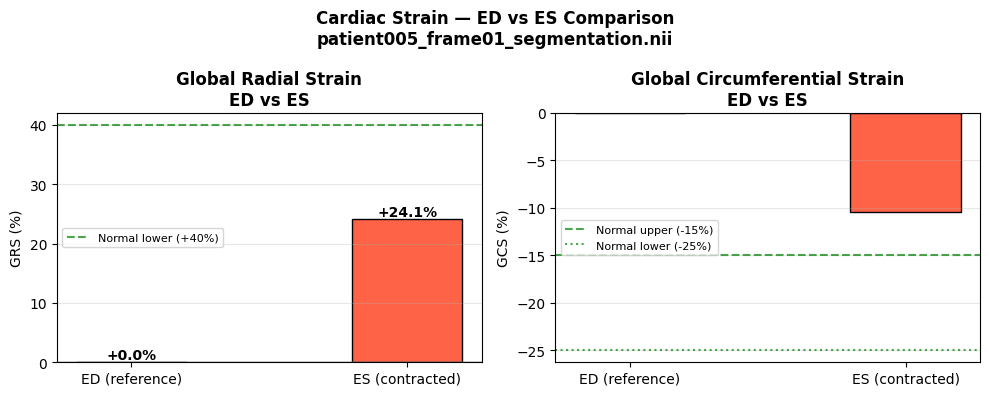

In [10]:
if MODE == 'A':
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    x = np.arange(n_frames)

    axes[0].plot(x, global_grs, 'o-', color='steelblue', lw=2, ms=4, label='Global GRS')
    axes[0].axhline(y=40, color='green', ls='--', alpha=0.6, label='Normal lower (+40%)')
    axes[0].axhline(y=0,  color='gray',  ls='-',  alpha=0.3)
    axes[0].axvline(x=ed_frame, color='blue',   ls=':', alpha=0.7, label=f'ED (frame {ed_frame})')
    axes[0].axvline(x=es_frame, color='orange', ls=':', alpha=0.7, label=f'ES (frame {es_frame})')
    axes[0].scatter([peak_grs_f], [global_grs[peak_grs_f]], color='red', zorder=5, s=80,
                    label=f'Peak GRS: {global_grs[peak_grs_f]:+.1f}%')
    axes[0].set_ylabel('GRS (%)')
    axes[0].set_title('Global Radial Strain vs Frame (relative to ED)', fontweight='bold')
    axes[0].legend(fontsize=8, ncol=2)
    axes[0].grid(alpha=0.3)

    axes[1].plot(x, global_gcs, 's-', color='tomato', lw=2, ms=4, label='Global GCS')
    axes[1].axhline(y=-15, color='green', ls='--', alpha=0.6, label='Normal upper (-15%)')
    axes[1].axhline(y=-25, color='green', ls=':',  alpha=0.6, label='Normal lower (-25%)')
    axes[1].axhline(y=0,   color='gray',  ls='-',  alpha=0.3)
    axes[1].axvline(x=ed_frame, color='blue',   ls=':', alpha=0.7, label=f'ED (frame {ed_frame})')
    axes[1].axvline(x=es_frame, color='orange', ls=':', alpha=0.7, label=f'ES (frame {es_frame})')
    axes[1].scatter([peak_gcs_f], [global_gcs[peak_gcs_f]], color='darkred', zorder=5, s=80,
                    label=f'Peak GCS: {global_gcs[peak_gcs_f]:+.1f}%')
    axes[1].set_ylabel('GCS (%)')
    axes[1].set_xlabel('Frame')
    axes[1].set_title('Global Circumferential Strain vs Frame (relative to ED)', fontweight='bold')
    axes[1].legend(fontsize=8, ncol=2)
    axes[1].grid(alpha=0.3)
    axes[1].set_xticks(x)

    fig.suptitle(f'Cardiac Strain Curves\n{os.path.basename(NIFTI_PATH)}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

elif MODE == 'B':
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    categories = ['ED (reference)', 'ES (contracted)']
    grs_vals = [global_grs[0], global_grs[1]]
    gcs_vals = [global_gcs[0], global_gcs[1]]

    colors_bars = ['steelblue', 'tomato']
    axes[0].bar(categories, grs_vals, color=colors_bars, edgecolor='black', width=0.4)
    axes[0].axhline(y=40, color='green', ls='--', alpha=0.7, label='Normal lower (+40%)')
    axes[0].axhline(y=0,  color='gray',  ls='-',  alpha=0.3)
    axes[0].set_ylabel('GRS (%)')
    axes[0].set_title('Global Radial Strain\nED vs ES', fontweight='bold')
    axes[0].legend(fontsize=8)
    axes[0].grid(axis='y', alpha=0.3)
    for bar, val in zip(axes[0].patches, grs_vals):
        if not np.isnan(val):
            axes[0].text(bar.get_x()+bar.get_width()/2,
                         bar.get_height()+0.5, f'{val:+.1f}%',
                         ha='center', fontsize=10, fontweight='bold')

    axes[1].bar(categories, gcs_vals, color=colors_bars, edgecolor='black', width=0.4)
    axes[1].axhline(y=-15, color='green', ls='--', alpha=0.7, label='Normal upper (-15%)')
    axes[1].axhline(y=-25, color='green', ls=':',  alpha=0.7, label='Normal lower (-25%)')
    axes[1].axhline(y=0,   color='gray',  ls='-',  alpha=0.3)
    axes[1].set_ylabel('GCS (%)')
    axes[1].set_title('Global Circumferential Strain\nED vs ES', fontweight='bold')
    axes[1].legend(fontsize=8)
    axes[1].grid(axis='y', alpha=0.3)
    for bar, val in zip(axes[1].patches, gcs_vals):
        if not np.isnan(val):
            axes[1].text(bar.get_x()+bar.get_width()/2,
                         bar.get_height()-1.5, f'{val:+.1f}%',
                         ha='center', fontsize=10, fontweight='bold', color='white')

    fig.suptitle(f'Cardiac Strain — ED vs ES Comparison\n{os.path.basename(NIFTI_ED_PATH or "")}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


## 8. AHA 17-Segment Bullseye at Peak Strain

Shows the per-segment strain distribution at the peak transition for GRS and GCS separately.

**Orientation:** Anterior top (90°), Lateral left (180°), Inferior bottom (270°), Septal right (0°).  
**Rings:** Basal (outer, segments 1–6), Mid (segments 7–12), Apical (segments 13–16), Apex (centre, segment 17).

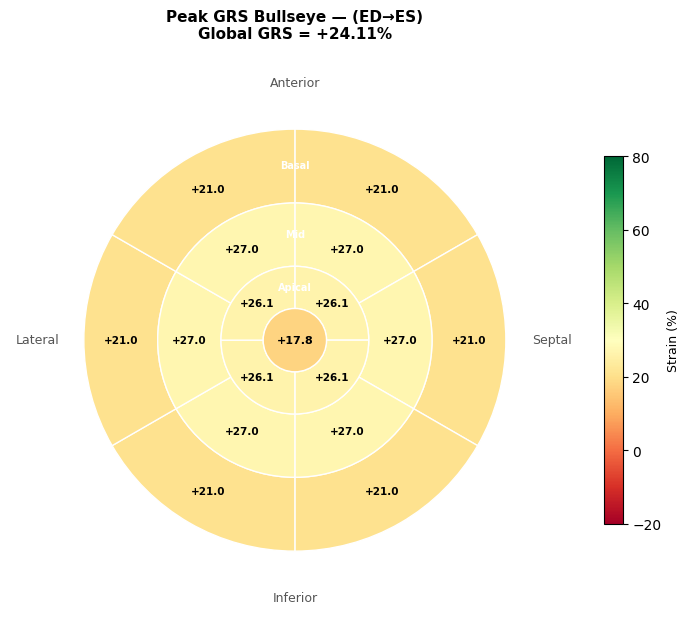

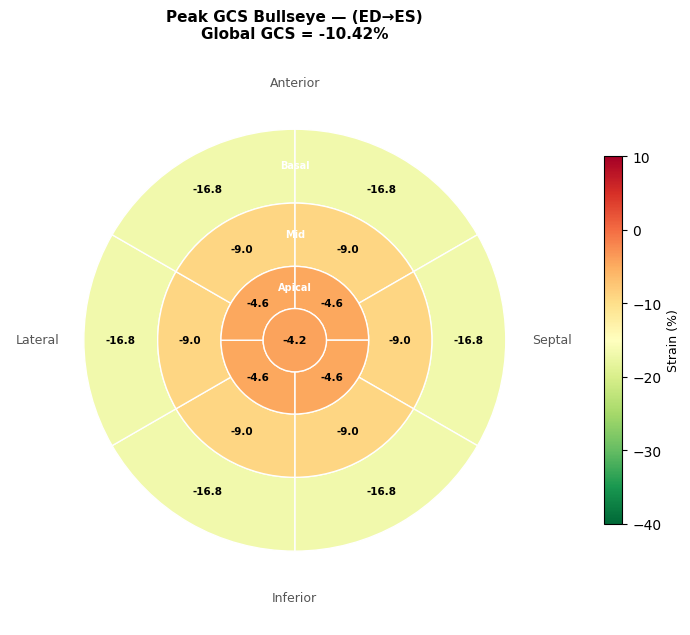

In [11]:
def draw_strain_bullseye(seg_values, title, cmap_name, vmin, vmax, unit='%'):
    """
    Draw AHA 17-segment bullseye coloured by strain value.

    Orientation: Anterior top (90 deg), Lateral left (180 deg),
                 Inferior bottom (270 deg), Septal right (0 deg).
    Segments 1-6 basal (outer), 7-12 mid, 13-16 apical, 17 apex (centre).
    """
    cmap = plt.cm.get_cmap(cmap_name)
    norm = Normalize(vmin=vmin, vmax=vmax)

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=12)

    rings = [
        (seg_values[0:6],   0.65, 1.0,  6, 90),   # Basal
        (seg_values[6:12],  0.35, 0.65, 6, 90),   # Mid
        (seg_values[12:16], 0.15, 0.35, 4, 90),   # Apical
    ]
    for segs, r_in, r_out, n_sec, start in rings:
        sec_ang = 360 / n_sec
        for i, v in enumerate(segs):
            t1 = start - (i + 1) * sec_ang
            t2 = start - i * sec_ang
            color = cmap(norm(v)) if not np.isnan(v) else '#888888'
            ax.add_patch(Wedge((0, 0), r_out, t1, t2,
                               width=r_out - r_in, color=color, ec='white', lw=1.0))
            mid_ang = np.deg2rad((t1 + t2) / 2)
            mid_r   = (r_in + r_out) / 2
            lbl = f'{v:+.1f}' if not np.isnan(v) else 'N/A'
            ax.text(mid_r * np.cos(mid_ang), mid_r * np.sin(mid_ang), lbl,
                    ha='center', va='center', fontsize=7.5,
                    color='black', fontweight='bold')

    # Apex centre circle
    v17 = seg_values[16]
    c17 = cmap(norm(v17)) if not np.isnan(v17) else '#888888'
    ax.add_patch(plt.Circle((0, 0), 0.15, color=c17, ec='white', lw=1.0))
    ax.text(0, 0, f'{v17:+.1f}' if not np.isnan(v17) else 'N/A',
            ha='center', va='center', fontsize=8,
            color='black', fontweight='bold')

    # Anatomical labels
    for lbl, pos in [('Anterior', (0, 1.22)), ('Inferior', (0, -1.22)),
                      ('Lateral', (-1.22, 0)), ('Septal', (1.22, 0))]:
        ax.text(pos[0], pos[1], lbl, ha='center', va='center',
                fontsize=9, color='#555555')

    # Ring labels
    for lbl, y in [('Basal', 0.83), ('Mid', 0.50), ('Apical', 0.25)]:
        ax.text(0, y, lbl, ha='center', va='center',
                fontsize=7, color='white', fontweight='bold')

    # Colourbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
    cbar.set_label(f'Strain ({unit})', fontsize=9)
    plt.tight_layout()
    plt.show()


# Update title to reflect mode
title_suffix = '(ED→ES)' if MODE == 'B' else f'Frame {peak_grs_f}'

draw_strain_bullseye(
    grs_all[peak_grs_f],
    title=f'Peak GRS Bullseye — {title_suffix}\nGlobal GRS = {global_grs[peak_grs_f]:+.2f}%',
    cmap_name='RdYlGn',
    vmin=-20, vmax=80
)
draw_strain_bullseye(
    gcs_all[peak_gcs_f],
    title=f'Peak GCS Bullseye — {title_suffix}\nGlobal GCS = {global_gcs[peak_gcs_f]:+.2f}%',
    cmap_name='RdYlGn_r',
    vmin=-40, vmax=10
)


## 9. Per-Segment Strain Heatmaps

Shows how each of the 17 AHA segments changes strain across all frame transitions.  
Rows = AHA segments, Columns = frame transitions.  
Useful for identifying regionally heterogeneous strain patterns.

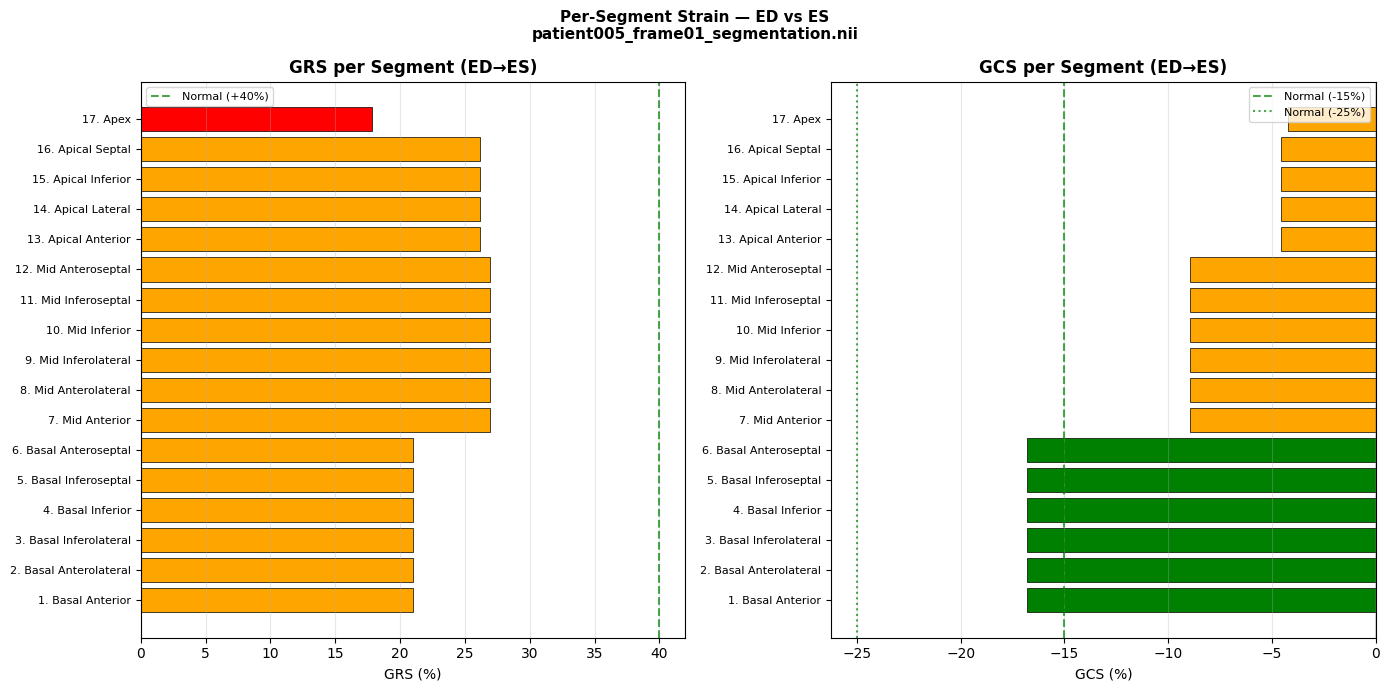

In [12]:
if MODE == 'A':
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    im1 = axes[0].imshow(grs_all.T, aspect='auto', cmap='RdYlGn', vmin=-20, vmax=80)
    axes[0].set_xlabel('Frame')
    axes[0].set_ylabel('AHA Segment')
    axes[0].set_title('GRS per Segment per Frame\n(relative to ED)', fontweight='bold')
    axes[0].set_xticks(range(n_frames))
    axes[0].set_xticklabels([str(f) for f in range(n_frames)], fontsize=7)
    axes[0].axvline(x=ed_frame, color='blue',   lw=2, ls='--', label=f'ED={ed_frame}')
    axes[0].axvline(x=es_frame, color='orange', lw=2, ls='--', label=f'ES={es_frame}')
    axes[0].set_yticks(range(17))
    axes[0].set_yticklabels([f'{i+1}. {n}' for i, n in enumerate(AHA_NAMES)], fontsize=7)
    axes[0].legend(fontsize=8)
    plt.colorbar(im1, ax=axes[0], label='GRS (%)')

    im2 = axes[1].imshow(gcs_all.T, aspect='auto', cmap='RdYlGn_r', vmin=-40, vmax=10)
    axes[1].set_xlabel('Frame')
    axes[1].set_ylabel('AHA Segment')
    axes[1].set_title('GCS per Segment per Frame\n(relative to ED)', fontweight='bold')
    axes[1].set_xticks(range(n_frames))
    axes[1].set_xticklabels([str(f) for f in range(n_frames)], fontsize=7)
    axes[1].axvline(x=ed_frame, color='blue',   lw=2, ls='--', label=f'ED={ed_frame}')
    axes[1].axvline(x=es_frame, color='orange', lw=2, ls='--', label=f'ES={es_frame}')
    axes[1].set_yticks(range(17))
    axes[1].set_yticklabels([f'{i+1}. {n}' for i, n in enumerate(AHA_NAMES)], fontsize=7)
    axes[1].legend(fontsize=8)
    plt.colorbar(im2, ax=axes[1], label='GCS (%)')

    fig.suptitle(f'Strain Heatmap — All Segments All Frames\n{os.path.basename(NIFTI_PATH)}',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

elif MODE == 'B':
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    x = np.arange(17)

    grs_es = grs_all[1]   # ES frame — ED is always 0 by definition
    colors_grs = ['green' if (not np.isnan(v) and v >= 40)
                  else 'orange' if (not np.isnan(v) and v >= 20)
                  else 'red' for v in grs_es]
    axes[0].barh(x, grs_es, color=colors_grs, edgecolor='black', linewidth=0.5)
    axes[0].axvline(x=40, color='green', ls='--', alpha=0.7, label='Normal (+40%)')
    axes[0].axvline(x=0,  color='gray',  ls='-',  alpha=0.3)
    axes[0].set_yticks(x)
    axes[0].set_yticklabels([f'{i+1}. {n}' for i, n in enumerate(AHA_NAMES)], fontsize=8)
    axes[0].set_xlabel('GRS (%)')
    axes[0].set_title('GRS per Segment (ED→ES)', fontweight='bold')
    axes[0].legend(fontsize=8)
    axes[0].grid(axis='x', alpha=0.3)

    gcs_es = gcs_all[1]
    colors_gcs = ['green' if (not np.isnan(v) and -25 <= v <= -15)
                  else 'orange' if (not np.isnan(v) and (-35 < v < -25 or -15 < v <= 0))
                  else 'red' for v in gcs_es]
    axes[1].barh(x, gcs_es, color=colors_gcs, edgecolor='black', linewidth=0.5)
    axes[1].axvline(x=-15, color='green', ls='--', alpha=0.7, label='Normal (-15%)')
    axes[1].axvline(x=-25, color='green', ls=':',  alpha=0.7, label='Normal (-25%)')
    axes[1].axvline(x=0,   color='gray',  ls='-',  alpha=0.3)
    axes[1].set_yticks(x)
    axes[1].set_yticklabels([f'{i+1}. {n}' for i, n in enumerate(AHA_NAMES)], fontsize=8)
    axes[1].set_xlabel('GCS (%)')
    axes[1].set_title('GCS per Segment (ED→ES)', fontweight='bold')
    axes[1].legend(fontsize=8)
    axes[1].grid(axis='x', alpha=0.3)

    fig.suptitle(f'Per-Segment Strain — ED vs ES\n{os.path.basename(NIFTI_ED_PATH or "")}',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()


## 10. Summary Report

In [13]:
print('=' * 60)
print('         CARDIAC STRAIN ANALYSIS — SUMMARY')
print('=' * 60)
print(f'Mode    : {"B — Two files (ED + ES)" if MODE == "B" else "A — 4D file (full cycle)"}')
if MODE == 'B':
    print(f'ED file : {os.path.basename(NIFTI_ED_PATH or "?")}')
    print(f'ES file : {os.path.basename(NIFTI_ES_PATH or "?")}')
else:
    print(f'File    : {os.path.basename(NIFTI_PATH or "?")}')
    print(f'Frames  : {n_frames}')
print(f'Slices  : {n_slices}')
print(f'Voxel   : {vox_xy:.4f} mm/px')
print(f'ED frame: {ed_frame}')
print(f'ES frame: {es_frame}')
print()

if MODE == 'B':
    print('--- ED vs ES Strain per Segment ---')
    print(f'{"Seg":>3}  {"Name":<25}  {"GRS (%)": >9}  {"GCS (%)": >9}')
    print('-' * 52)
    for i, name in enumerate(AHA_NAMES):
        g = f'{grs_all[1,i]:+.2f}' if not np.isnan(grs_all[1,i]) else '   N/A'
        c = f'{gcs_all[1,i]:+.2f}' if not np.isnan(gcs_all[1,i]) else '   N/A'
        print(f'{i+1:>3}  {name:<25}  {g:>9}  {c:>9}')
    print()

print('--- Peak Values ---')
print(f'Peak GRS : {global_grs[peak_grs_f]:+.2f}%')
print(f'  Normal  : > +40%')
grs_i = ('NORMAL' if global_grs[peak_grs_f] >= 40 else
          'MILDLY REDUCED' if global_grs[peak_grs_f] >= 20 else 'REDUCED')
print(f'  Status  : {grs_i}')
print()
print(f'Peak GCS : {global_gcs[peak_gcs_f]:+.2f}%')
print(f'  Normal  : -15% to -25%')
gcs_i = ('NORMAL'       if -25 <= global_gcs[peak_gcs_f] <= -15 else
          'REDUCED'       if global_gcs[peak_gcs_f] > -15         else 'HYPERDYNAMIC')
print(f'  Status  : {gcs_i}')
print('=' * 60)


         CARDIAC STRAIN ANALYSIS — SUMMARY
Mode    : B — Two files (ED + ES)
ED file : patient005_frame01_segmentation.nii
ES file : patient005_frame13_segmentation.nii
Slices  : 10
Voxel   : 1.0000 mm/px
ED frame: 0
ES frame: 1

--- ED vs ES Strain per Segment ---
Seg  Name                         GRS (%)    GCS (%)
----------------------------------------------------
  1  Basal Anterior                +20.96     -16.81
  2  Basal Anterolateral           +20.96     -16.81
  3  Basal Inferolateral           +20.96     -16.81
  4  Basal Inferior                +20.96     -16.81
  5  Basal Inferoseptal            +20.96     -16.81
  6  Basal Anteroseptal            +20.96     -16.81
  7  Mid Anterior                  +26.95      -8.96
  8  Mid Anterolateral             +26.95      -8.96
  9  Mid Inferolateral             +26.95      -8.96
 10  Mid Inferior                  +26.95      -8.96
 11  Mid Inferoseptal              +26.95      -8.96
 12  Mid Anteroseptal              +26.95    